# Regional maps and saving figures

`latlon_range=[lat_min, lat_max, lon_min, lon_max]` crops the map to a box, and
`cbar_kwargs['ticks']` sets the colorbar ticks independently of the contour `levels`.
`x4c.savefig()` creates missing directories and trims whitespace on the way out.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
temp_path = os.path.join(
    case_dir, 'ocn', 'proc', 'tseries', 'month_1',
    f'{casename}.pop.h.TEMP.000101-000112.nc',
)
ds_temp = x4c.open_dataset(temp_path, comp='ocn', grid='g16', vn='TEMP', shift_time=True)
sst = ds_temp.x.da.isel(z_t=0).x.regrid().mean('time')
sst.attrs["long_name"] = "Sea Surface Temperature"

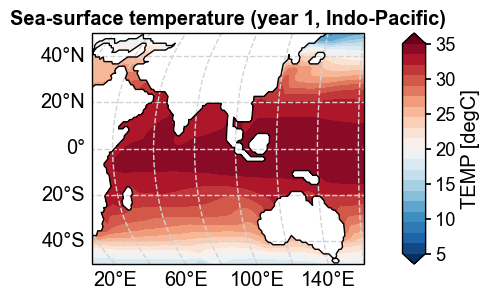

Figure saved at: "figs/SST_ann_regional.pdf"


In [3]:
x4c.set_style('journal_spines', font_scale=1.2)
fig, ax = sst.x.plot(
    levels=np.linspace(5, 35, 21),
    cbar_kwargs={'ticks': np.linspace(5, 35, 7)},
    add_gridlines=True,
    latlon_range=[-50, 50, 30, 160],
    title='Sea-surface temperature (year 1, Indo-Pacific)',
)
x4c.showfig(fig)
x4c.savefig(fig, './figs/SST_ann_regional.pdf')
x4c.set_style('journal')  # restore